# Week 5 — From language to numbers

A runnable notebook companion to the Week 5 course page.

This notebook follows the source page from top to bottom. It keeps the source's distinction between:

- 🧠 **Learn**: think, write, and check your reasoning.
- 🔬 **Tool**: run code, inspect the output, and change variables.
- 🚀 **Builder**: optional projects and extensions.

The central habit for this week is: **run the examples, change a value, break something on purpose, and inspect the result**.

Source: `data/week5/Week 5 · From language to numbers · 02805.html`


## How to use this notebook

Run the setup cell first. Then work downward.

The notebook is designed to work with what is already in this repository:

- the Week 1 Marvel node descriptions in `data/week1/week1_nodes.tsv`;
- the Week 5 HTML page and its local explorable assets.

The source page also asks you to use the full `marvel_pages.zip` corpus. That file is **not present in this repository**, so the full-page cells will explain what is missing instead of inventing results. If you add the ZIP later, rerun the relevant cells.

Some source examples use optional libraries. Cells that need them will say so clearly. The standard-library examples remain useful even before those packages are installed.


In [1]:
from pathlib import Path
import csv
import importlib.util
import re

def find_repo_root():
    candidates = [Path.cwd(), *Path.cwd().parents]
    for candidate in candidates:
        if (candidate / "data" / "week1" / "week1_nodes.tsv").exists():
            return candidate
    raise FileNotFoundError(
        "Could not find the repository root. Open the notebook from inside Go_Nuts_repos."
    )

REPO_ROOT = find_repo_root()
DATA_DIR = REPO_ROOT / "data"
WEEK1_NODES = DATA_DIR / "week1" / "week1_nodes.tsv"
WEEK5_DIR = DATA_DIR / "week5"

available = {
    name: importlib.util.find_spec(name) is not None
    for name in ["spacy", "nltk", "sklearn", "matplotlib", "tiktoken"]
}

print("Repository:", REPO_ROOT)
print("Week 1 nodes:", WEEK1_NODES)
print("Optional packages:", available)


Repository: c:\Users\victo\Codex\Go_Nuts_repos
Week 1 nodes: c:\Users\victo\Codex\Go_Nuts_repos\data\week1\week1_nodes.tsv
Optional packages: {'spacy': True, 'nltk': True, 'sklearn': False, 'matplotlib': True, 'tiktoken': True}


In [2]:
def read_week1_nodes(path):
    with path.open(encoding="utf-8-sig", newline="") as handle:
        lines = (line for line in handle if not line.startswith("#"))
        return list(csv.DictReader(lines, delimiter="\t"))

week1_nodes = read_week1_nodes(WEEK1_NODES)
descriptions_by_id = {
    row["node_id"]: row["description"]
    for row in week1_nodes
    if row.get("description")
}
description_documents = list(descriptions_by_id.values())

print("Marvel node descriptions:", len(description_documents))
print("First description:", description_documents[0])


Marvel node descriptions: 303
First description: The Abomination (Emil Blonsky) is a character appearing in American comic books published by Marvel Comics.


In [3]:
def fallback_tokenize(text):
    """A transparent fallback; the source's preferred word-like tokenizer is spaCy."""
    return re.findall(r"\w+|[^\w\s]", text, flags=re.UNICODE)

try:
    import spacy
    nlp = spacy.load("en_core_web_sm")
    print("spaCy is ready.")
except Exception as exc:
    nlp = None
    print("spaCy/en_core_web_sm is not ready:", exc)
    print("The notebook will use a simple fallback tokenizer where possible.")

def word_like_tokens(text):
    if nlp is not None:
        return [token.text for token in nlp(text)]
    return fallback_tokenize(text)

marvel_tokens = [
    token.lower()
    for document in description_documents
    for token in word_like_tokens(document)
]

print("Tokens from local Week 1 descriptions:", len(marvel_tokens))
print("First 30 tokens:", marvel_tokens[:30])


spaCy is ready.
Tokens from local Week 1 descriptions: 6193
First 30 tokens: ['the', 'abomination', '(', 'emil', 'blonsky', ')', 'is', 'a', 'character', 'appearing', 'in', 'american', 'comic', 'books', 'published', 'by', 'marvel', 'comics', '.', 'adam', 'warlock', 'is', 'a', 'character', 'appearing', 'in', 'american', 'comic', 'books', 'published']


## 0. Format change and the Week 5 aim

The page changes from paper-first network calculations to notebook-first language experiments. The stated workflow is:

1. turn raw text into data;
2. count what is there;
3. inspect examples;
4. understand what preprocessing choices change;
5. only then move to more complicated analysis.

Wikipedia remains the playground: each Marvel network node is also a text document.

The page recommends reading:

- Jurafsky & Martin, [Chapter 1](https://web.stanford.edu/~jurafsky/slp3/1.pdf);
- Jurafsky & Martin, [Chapter 2 — Words and Tokens](https://web.stanford.edu/~jurafsky/slp3/2.pdf);
- the [NLTK Chapter 1](https://www.nltk.org/book/ch01.html).

The local browser explorables are still available from the source page. For example:

- [token pipeline](../data/week5/Week%205%20%C2%B7%20From%20language%20to%20numbers%20%C2%B7%2002805_files/token-pipeline.html)
- [Zipf language](../data/week5/Week%205%20%C2%B7%20From%20language%20to%20numbers%20%C2%B7%2002805_files/zipf-language.html)
- [n-gram window](../data/week5/Week%205%20%C2%B7%20From%20language%20to%20numbers%20%C2%B7%2002805_files/ngram-window.html)
- [document vectors](../data/week5/Week%205%20%C2%B7%20From%20language%20to%20numbers%20%C2%B7%2002805_files/document-vectors.html)
- [lookalikes](../data/week5/Week%205%20%C2%B7%20From%20language%20to%20numbers%20%C2%B7%2002805_files/lookalikes.html)


## 1. Why language?

Language is treated as data about people: what people talk about, the distinctions they make, and how they describe the world. NLP is the toolbox for turning language into representations a computer can analyze, interpret, or generate.

At a high level, a causal language model repeatedly:

- assigns probabilities to possible next tokens;
- picks one;
- adds it to the text;
- repeats the process.

The Week 5 browser page includes a toy next-token generator. Its probabilities are hand-written teaching values, not a neural network. The point is to notice the repeated next-token loop and its stochastic output.


## 2. From raw text to tokens

A computer starts with characters, not words. **Tokenization** decides where one text unit ends and the next begins.

There is no single objectively correct tokenization. Different tokenizers can reasonably split the same string differently. Lowercasing, punctuation filtering, stopword removal, and lemmatization happen after tokenization and can remove information.

A useful distinction from the source:

- a **token** is one occurrence;
- a **type** is one distinct token form;
- the **vocabulary** is the set of types kept by the representation;
- **subword tokenization** represents text using reusable pieces smaller than whole words;
- a **token ID** is an integer pointing into a model vocabulary.


In [4]:
raw = "Iron Man wasn't in New York."

raw.split()
# ['Iron', 'Man', "wasn't", 'in', 'New', 'York.']


['Iron', 'Man', "wasn't", 'in', 'New', 'York.']

The simple `split()` tokenizer keeps `wasn't` together and leaves the full stop attached to `York.`. A more language-aware tokenizer might produce:

`['Iron', 'Man', 'was', "n't", 'in', 'New', 'York', '.']`

Neither choice is automatically “natural”; each reflects modeling decisions.


In [5]:
raw = "Marvel's heroes weren't fighting in New York."

if nlp is None:
    print("Install spaCy and the English model to run the source's spaCy example:")
    print("  python -m pip install spacy")
    print("  python -m spacy download en_core_web_sm")
else:
    doc = nlp(raw)
    [token.text for token in doc]


In [6]:
if nlp is None:
    print("spaCy is not available yet.")
else:
    lower = [token.text.lower() for token in doc]
    no_punct = [token.text for token in doc if not token.is_punct]
    no_stop = [token.text for token in doc if not token.is_stop]
    lemmas = [token.lemma_ for token in doc]

    print("lower:", lower)
    print("no_punct:", no_punct)
    print("no_stop:", no_stop)
    print("lemmas:", lemmas)


lower: ['marvel', "'s", 'heroes', 'were', "n't", 'fighting', 'in', 'new', 'york', '.']
no_punct: ['Marvel', "'s", 'heroes', 'were', "n't", 'fighting', 'in', 'New', 'York']
no_stop: ['Marvel', 'heroes', 'fighting', 'New', 'York', '.']
lemmas: ['Marvel', "'s", 'hero', 'be', 'not', 'fight', 'in', 'New', 'York', '.']


### 🧠 Learn 5.1 — Did you really read it? · language and tokens

No notebook, no chatbot first. Think, then write.

1. The toy next-token generator assumes the text has been split into tokens and that a probability table exists for what comes next. Which part is decided by the tokenizer, and which part must the language model learn from training data?
2. Explain **token**, **type**, and **vocabulary** using a sentence of your own. What can happen to the number of types if you lowercase?
3. Put these in order and explain each step: token IDs, raw characters, tokenizer, model, token pieces. Which step decides that *New York* is two pieces rather than one?
4. Pick one of lowercasing, stopword removal, or lemmatization. Give one research question where it is probably harmless and one where it could destroy the signal.
5. From Jurafsky & Martin Chapter 2: explain what BPE starts from, what it repeats, when it stops, and why starting from single characters means a word is never completely unknown.


## 🟨 ANSWER KEY — Learn 5.1

> **Try the questions first, then use this highlighted section to check your reasoning.**

1. The tokenizer decides how raw characters are split into token pieces. The language model learns the probabilities of which token is likely to come next from its training data. The tokenizer does not decide the meaning or next-token probabilities.

2. Example: `Dogs chase dogs.` contains four token occurrences if punctuation is kept: `Dogs`, `chase`, `dogs`, and `.`. Keeping capitalization gives four types. Lowercasing gives `dogs`, `chase`, `dogs`, and `.`, so the number of types falls to three because `Dogs` and `dogs` become one type.

3. The order is: **raw characters → tokenizer → token pieces → token IDs → model**. The tokenizer decides whether `New York` is represented as two pieces, one piece, or several subword pieces. The token IDs are only the integer labels for the pieces chosen by that tokenizer.

4. Lowercasing is probably harmless when the question is about broad word frequency and capitalization carries no meaning. It could destroy signal in a question distinguishing `Apple` as a company or place from `apple` as a fruit, or `Big Apple` from `big apple`.

5. BPE starts from small units such as individual characters or bytes. It repeatedly merges frequent adjacent pairs, adding useful larger pieces to the vocabulary, until the chosen vocabulary size or stopping condition is reached. Starting from single characters means an unfamiliar word can still be represented as a sequence of known small pieces rather than becoming completely unknown.

### 🧠 Learn 5.2 — Tokenization, by hand

Paper first. Make the choices visible before a library makes them.

Use the sentence:

> Spider-Man didn't save Queens; Doctor Strange's portal did!

1. Write your rules for hyphens, apostrophes, and punctuation. Tokenize by hand and report token and type counts.
2. Predict what happens to the counts after lowercasing and after removing punctuation. Define a small stopword set, remove it, and predict again.
3. Explain why *New York* remaining as two tokens is not a tokenizer failure. Name a later NLP task that could treat the two tokens as one place, and give another example where token boundaries and the thing of interest differ.
4. Use this subword vocabulary: *un, believ, able, spider, man, hat, tan, wak, anda*, plus every single letter. Lowercase and split left-to-right, always taking the longest fitting piece. Segment *unbelievable*, *Spiderman*, *Wakanda*, *Manhattan*, and *Thanos*. Which costs the most tokens, and why is representation still better than no representation?
5. For comparing how *power* is used across two Marvel communities, choose whether to lowercase, lemmatize, or remove stopwords. Defend the choices, including what happens to relative frequency if stopwords are removed.


## 🟨 ANSWER KEY — Learn 5.2

> **One consistent hand-tokenization is enough; the important part is stating the rules.**

1. One defensible rule is to keep hyphenated names together, split contractions into word pieces, and keep punctuation as separate tokens. That gives:

   `Spider-Man`, `did`, `n't`, `save`, `Queens`, `;`, `Doctor`, `Strange`, `'s`, `portal`, `did`, `!`

   There are 12 token occurrences and 11 types because `did` occurs twice. Other boundary choices are not automatically wrong if they are stated and used consistently.

2. Lowercasing leaves the token count at 12 and leaves the type count at 11 for this particular sentence, because no two otherwise-distinct tokens become equal. Removing `;` and `!` leaves 10 tokens and 9 types. If the chosen stopword set is `{did, n't}`, removing it as well leaves 7 tokens: `Spider-Man`, `save`, `Queens`, `Doctor`, `Strange`, `'s`, `portal`. Counts can stay unchanged when a preprocessing rule does not affect any repeated distinction in the particular sentence.

3. Keeping `New` and `York` as two tokens is a tokenizer decision, not a failure. Named-entity recognition can later label the pair as one location, `New York`. Another example is `Spider-Man`: the tokenizer may split or keep the hyphenated form, while the research question may care about the character as one entity.

4. Longest-match segmentation gives:

   - `unbelievable` → `un` + `believ` + `able` — 3 pieces
   - `Spiderman` → `spider` + `man` — 2 pieces
   - `Wakanda` → `wak` + `anda` — 2 pieces
   - `Manhattan` → `man` + `hat` + `tan` — 3 pieces
   - `Thanos` → `t` + `h` + `a` + `n` + `o` + `s` — 6 pieces

   `Thanos` costs the most under this vocabulary. It is still representable because every letter is available, so the model receives a sequence of IDs instead of an unknown whole word.

5. I would lowercase so `Power` and `power` are counted together unless capitalization is itself part of the research question. I would not automatically lemmatize, because `power`, `powered`, and `powering` may represent different uses; I would test the effect and report it. I would be cautious about stopword removal: it does not remove a `power` token, but it reduces the denominator of total tokens, so the relative frequency of `power` can increase.

### 🔬 Tool 5.3 — Tokenization, as code

The source asks you to compare:

- your hand tokenization;
- spaCy's word-like tokens;
- the subword tokenizer `tiktoken.get_encoding("o200k_base")`.

Run the cell below after filling in your hand tokenization. Look closely at spaces and explain at least two disagreements.


In [7]:
sentence_5_2 = "Spider-Man didn't save Queens; Doctor Strange's portal did!"

# Replace this with the tokenization you wrote by hand.
hand_tokens = [
    "Spider-Man", "did", "n't", "save", "Queens", ";",
    "Doctor", "Strange", "'s", "portal", "did", "!"
]

spacy_tokens = word_like_tokens(sentence_5_2)
print("Hand tokens:", hand_tokens)
print("spaCy/fallback tokens:", spacy_tokens)

try:
    import tiktoken
    enc = tiktoken.get_encoding("o200k_base")
    ids = enc.encode(sentence_5_2)
    subword_pieces = [enc.decode([i]) for i in ids]
    print("o200k_base IDs:", ids)
    print("o200k_base pieces:", subword_pieces)
except Exception as exc:
    print("tiktoken is not ready:", exc)
    print("Install it with: python -m pip install tiktoken")


Hand tokens: ['Spider-Man', 'did', "n't", 'save', 'Queens', ';', 'Doctor', 'Strange', "'s", 'portal', 'did', '!']
spaCy/fallback tokens: ['Spider', '-', 'Man', 'did', "n't", 'save', 'Queens', ';', 'Doctor', 'Strange', "'s", 'portal', 'did', '!']
o200k_base IDs: [105564, 59466, 9289, 5093, 44979, 26, 28570, 101854, 885, 26883, 2242, 0]
o200k_base pieces: ['Spider', '-Man', " didn't", ' save', ' Queens', ';', ' Doctor', ' Strange', "'s", ' portal', ' did', '!']


In [8]:
if nlp is None:
    print("The token attribute table needs spaCy and en_core_web_sm.")
else:
    token_table = [
        {
            "text": token.text,
            "lower": token.text.lower(),
            "is_stop": token.is_stop,
            "is_punct": token.is_punct,
            "lemma": token.lemma_,
        }
        for token in nlp(sentence_5_2)
    ]
    for row in token_table:
        print(row)


{'text': 'Spider', 'lower': 'spider', 'is_stop': False, 'is_punct': False, 'lemma': 'Spider'}
{'text': '-', 'lower': '-', 'is_stop': False, 'is_punct': True, 'lemma': '-'}
{'text': 'Man', 'lower': 'man', 'is_stop': False, 'is_punct': False, 'lemma': 'Man'}
{'text': 'did', 'lower': 'did', 'is_stop': True, 'is_punct': False, 'lemma': 'do'}
{'text': "n't", 'lower': "n't", 'is_stop': True, 'is_punct': False, 'lemma': 'not'}
{'text': 'save', 'lower': 'save', 'is_stop': False, 'is_punct': False, 'lemma': 'save'}
{'text': 'Queens', 'lower': 'queens', 'is_stop': False, 'is_punct': False, 'lemma': 'Queens'}
{'text': ';', 'lower': ';', 'is_stop': False, 'is_punct': True, 'lemma': ';'}
{'text': 'Doctor', 'lower': 'doctor', 'is_stop': False, 'is_punct': False, 'lemma': 'Doctor'}
{'text': 'Strange', 'lower': 'strange', 'is_stop': False, 'is_punct': False, 'lemma': 'Strange'}
{'text': "'s", 'lower': "'s", 'is_stop': True, 'is_punct': False, 'lemma': "'s"}
{'text': 'portal', 'lower': 'portal', 'is_st

For the Marvel part of Tool 5.3, `marvel_tokens` below comes from the local Week 1 **short descriptions**, not the unavailable full pages. The source asks you to report character count, token count, type count, and the five most frequent types before and after one preprocessing choice.


In [9]:
from collections import Counter

description_counts_raw = Counter(
    token for document in description_documents
    for token in word_like_tokens(document)
)
description_counts_lower = Counter(marvel_tokens)

print("Documents:", len(description_documents))
print("Raw character count:", sum(len(document) for document in description_documents))
print("Lowercased token count:", len(marvel_tokens))
print("Lowercased type count:", len(description_counts_lower))
print("Top five lowercased types:", description_counts_lower.most_common(5))


Documents: 303
Raw character count: 34870
Lowercased token count: 6193
Lowercased type count: 931
Top five lowercased types: [('by', 311), ('marvel', 306), ('in', 305), ('is', 302), ('comics', 302)]


### Heaps' law exercise scaffold

The source asks you to read pages one at a time and plot vocabulary size against token count. This cell runs the same idea over the local Week 1 descriptions, one description at a time. It is not a substitute for the full-page exercise; it is the available local corpus.


First five points: [(19, 19), (34, 21), (58, 31), (73, 32), (89, 33)]
Last point: (6193, 931)


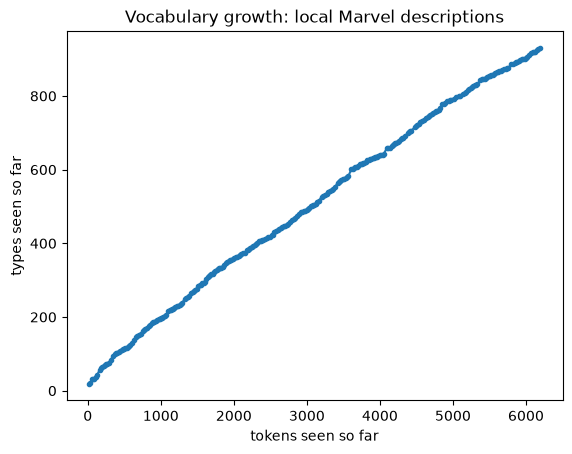

In [10]:
def vocabulary_growth(documents):
    seen = set()
    token_total = 0
    points = []

    for document in documents:
        tokens = [token.lower() for token in word_like_tokens(document)]
        token_total += len(tokens)
        seen.update(tokens)
        points.append((token_total, len(seen)))

    return points

description_growth = vocabulary_growth(description_documents)
print("First five points:", description_growth[:5])
print("Last point:", description_growth[-1])

try:
    import matplotlib.pyplot as plt
    x, y = zip(*description_growth)
    plt.plot(x, y, marker=".")
    plt.xlabel("tokens seen so far")
    plt.ylabel("types seen so far")
    plt.title("Vocabulary growth: local Marvel descriptions")
    plt.show()
except ImportError:
    print("Install matplotlib to plot the curve: python -m pip install matplotlib")


## Full Marvel pages checkpoint

The source uses `marvel_pages.zip`: 303 plain-text Wikipedia articles corresponding to the Week 1 characters. It says the course data page's loading snippet creates a dictionary keyed by `node_id`.

The ZIP is expected at `notebooks/data/marvel_pages.zip`. The next cell loads its 303 page files and deliberately shows the archive member names so you can verify how they map to `node_id` before joining the language to the network.


In [11]:
from zipfile import ZipFile

zip_candidates = [
    Path(r"C:\Users\victo\Codex\Go_Nuts_repos\notebooks\data\marvel_pages.zip"),
]
FULL_PAGES_ZIP = next((path for path in zip_candidates if path.exists()), None)
full_documents = {}

if FULL_PAGES_ZIP is None:
    print("marvel_pages.zip is not present.")
    print("Add it to one of these locations and rerun this cell:")
    for path in zip_candidates:
        print(" -", path)
else:
    with ZipFile(FULL_PAGES_ZIP) as archive:
        members = [
            info.filename
            for info in archive.infolist()
            if (
                not info.is_dir()
                and info.filename.lower().endswith(".txt")
                and not info.filename.lower().endswith("readme.txt")
            )
        ]
        full_documents = {
            member: archive.read(member).decode("utf-8", errors="replace")
            for member in members
        }
    print("Loaded text files:", len(full_documents))
    print("First archive members:", list(full_documents)[:5])
    print("Verify member names against Week 1 node_id before joining to the network.")


Loaded text files: 303
First archive members: ['marvel_pages/Abomination_(character).txt', 'marvel_pages/Adam_Warlock.txt', 'marvel_pages/Agent_X_(Marvel_Comics).txt', 'marvel_pages/Ajak.txt', 'marvel_pages/Alex_Wilder.txt']
Verify member names against Week 1 node_id before joining to the network.


## 3. Counting language, the old-school way

Count first. The source compares this to basic network sanity checks: before a complex model, inspect the underlying data.

Important quantities:

- total number of tokens;
- number of different types;
- number of hapax types, which occur exactly once;
- raw frequency;
- relative frequency, which divides a count by the total number of tokens.


In [12]:
tokens = [
    "iron", "man", "fights", "the", "villain", ".",
    "the", "villain", "escapes", "to", "new", "york", ".",
    "iron", "man", "follows", "the", "villain", "to", "new", "york", ".",
    "the", "city", "thanks", "iron", "man", "."
]

len(tokens)


28

In [13]:
from collections import Counter

counts = Counter(tokens)
counts.most_common(10)

[('the', 4),
 ('.', 4),
 ('iron', 3),
 ('man', 3),
 ('villain', 3),
 ('to', 2),
 ('new', 2),
 ('york', 2),
 ('fights', 1),
 ('escapes', 1)]

The source output is:

`[('the', 4), ('.', 4), ('iron', 3), ('man', 3), ('villain', 3), ('to', 2), ('new', 2), ('york', 2), ('fights', 1), ('escapes', 1)]`

Check the `the` count yourself before trusting the output.


In [14]:
n_tokens = len(tokens)
n_types = len(counts)
n_hapax = sum(n == 1 for n in counts.values())

n_tokens, n_types, n_hapax
# (28, 13, 5)


(28, 13, 5)

In [15]:
total = len(tokens)
relative_frequency = {
    word: count / total
    for word, count in counts.items()
}

relative_frequency

{'iron': 0.10714285714285714,
 'man': 0.10714285714285714,
 'fights': 0.03571428571428571,
 'the': 0.14285714285714285,
 'villain': 0.10714285714285714,
 '.': 0.14285714285714285,
 'escapes': 0.03571428571428571,
 'to': 0.07142857142857142,
 'new': 0.07142857142857142,
 'york': 0.07142857142857142,
 'follows': 0.03571428571428571,
 'city': 0.03571428571428571,
 'thanks': 0.03571428571428571}

In [18]:
try:
    from nltk import FreqDist
    fd = FreqDist(tokens)
    print("Most common:", fd.most_common(10))
    print("First hapaxes:", fd.hapaxes()[:10])
except Exception as exc:
    print("NLTK is not ready:", exc)
    print("Install it with: python -m pip install nltk")


Most common: [('the', 4), ('.', 4), ('iron', 3), ('man', 3), ('villain', 3), ('to', 2), ('new', 2), ('york', 2), ('fights', 1), ('escapes', 1)]
First hapaxes: ['fights', 'escapes', 'follows', 'city', 'thanks']


### Zipf's law

The source gives the idealized relationship:

`f(r) ∝ 1 / r^s`

where `r` is frequency rank and `f(r)` is frequency. A log-log plot can look approximately straight, but that alone does not prove an exact Zipf law.


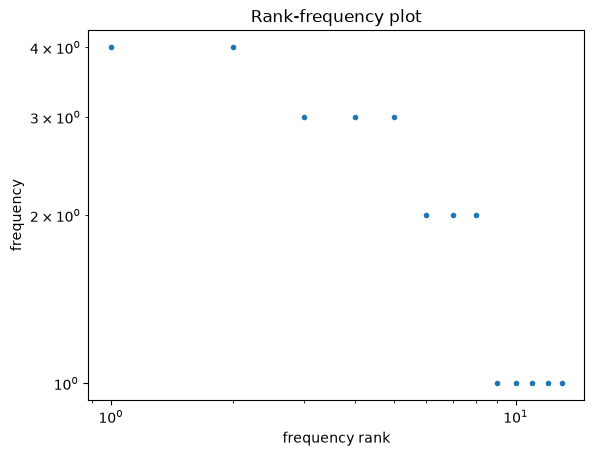

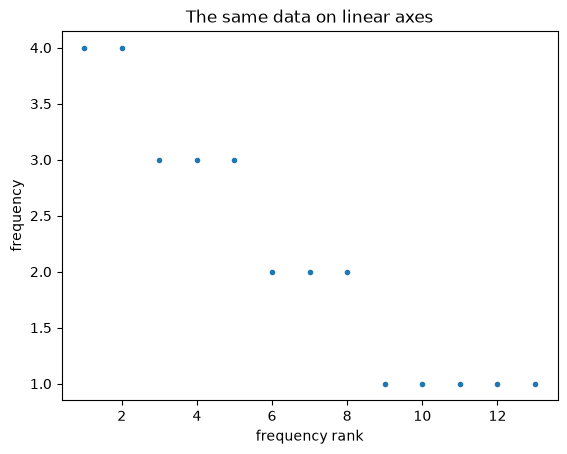

In [19]:
try:
    import matplotlib.pyplot as plt

    frequencies = sorted(counts.values(), reverse=True)
    ranks = range(1, len(frequencies) + 1)

    plt.loglog(ranks, frequencies, ".")
    plt.xlabel("frequency rank")
    plt.ylabel("frequency")
    plt.title("Rank-frequency plot")
    plt.show()

    # Same data on linear axes.
    plt.plot(ranks, frequencies, ".")
    plt.xlabel("frequency rank")
    plt.ylabel("frequency")
    plt.title("The same data on linear axes")
    plt.show()
except ImportError:
    print("Install matplotlib to plot: python -m pip install matplotlib")


### Marvel frequency counts

This runs the source's counting and rank-frequency ideas on the local Week 1 descriptions. State the preprocessing choice explicitly: here it is lowercase word-like tokens, including punctuation if the fallback tokenizer produces it.


Total tokens: 6193
Types: 931
Hapax types: 698
Top 10: [('by', 311), ('marvel', 306), ('in', 305), ('is', 302), ('comics', 302), ('comic', 300), ('.', 299), ('published', 298), ('books', 294), ('appearing', 286)]


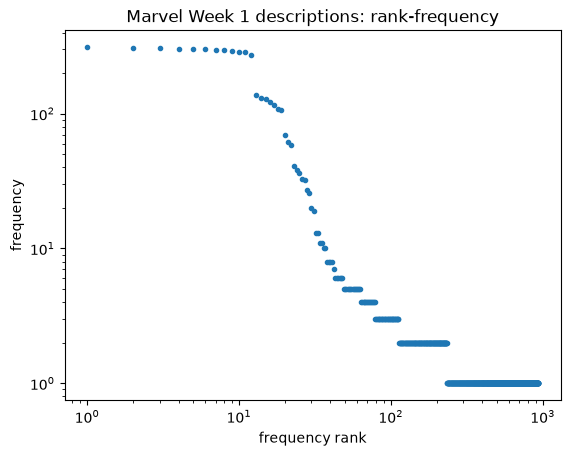

In [20]:
description_counts = Counter(marvel_tokens)
description_frequencies = sorted(description_counts.values(), reverse=True)

print("Total tokens:", len(marvel_tokens))
print("Types:", len(description_counts))
print("Hapax types:", sum(count == 1 for count in description_counts.values()))
print("Top 10:", description_counts.most_common(10))

try:
    import matplotlib.pyplot as plt
    ranks = range(1, len(description_frequencies) + 1)
    plt.loglog(ranks, description_frequencies, ".")
    plt.xlabel("frequency rank")
    plt.ylabel("frequency")
    plt.title("Marvel Week 1 descriptions: rank-frequency")
    plt.show()
except ImportError:
    print("Install matplotlib to plot.")


### 🧠 + 🔬 Learn/Tool 5.4 — Is Marvel Zipf-like?

Reason first, then calculate.

1. Look at idealized and observed curves. Give two reasons the Marvel curve might deviate from the idealized one. Predict what changes when moving from short descriptions to full pages.
2. Load the full raw Marvel pages. Under one stated preprocessing choice, report total tokens, types, hapax types, and the ten most frequent types.
3. Plot frequency against rank on linear and log-log axes. Compare full pages, short descriptions, and the idealized curve. Does the larger corpus look more Zipf-like?
4. Is a straight-ish log-log line enough to conclude that the corpus follows Zipf's law? State what the figure supports, what it does not establish, and what else you would check.
5. Name one corpus you expect to be more Zipf-like and one less Zipf-like. Explain why. The source suggests NLTK's `gutenberg` corpus and `melville-moby_dick.txt` as one possible comparison.


## 🟨 ANSWER KEY — Learn 5.4

> **The conceptual answers are below. The full-page numerical results must come from your own `marvel_pages.zip` run.**

1. The observed Marvel-description curve can deviate from an idealized Zipf curve because the corpus is small and because Wikipedia descriptions may reuse templated phrases such as publication language. Tokenization, capitalization, punctuation, and the genre of the text also affect the counts. Moving to full pages should increase the number of tokens and types and usually make the frequency distribution smoother, but repeated Wikipedia boilerplate can still create unusually frequent terms.

2. The correct answer is a reported measurement, not a value that can be inferred from the Week 5 page. State the preprocessing first—for example, lowercase word-like tokens with punctuation either kept or removed—then report `len(tokens)`, `len(Counter(tokens))`, the number of counts equal to 1, and `Counter(tokens).most_common(10)`. Run the full-page cells to obtain the numerical result from the provided ZIP.

3. Plot the same rank and frequency values twice: once with ordinary axes and once with `loglog`. Compare the local short-description plot with the full-page plot and the idealized curve. A larger corpus may look more regular because it contains more observations, but repeated templates or preprocessing choices can still produce deviations.

4. No. A straight-ish line on log-log axes is evidence that the data have a roughly power-law-like rank-frequency shape over the plotted range. It does not prove an exact Zipf law. I would also check the corpus size, the preprocessing, the range over which the line holds, residuals or goodness of fit, the estimated exponent, and whether other distributions explain the data at least as well.

5. A large, varied natural-language collection such as a full novel is a reasonable candidate to look more Zipf-like because it contains many tokens and varied usage. A small set of templated descriptions is a reasonable candidate to look less Zipf-like because repeated wording and a limited genre create artificial frequency peaks. These are predictions to test, not conclusions before plotting.

In [ ]:
if full_documents:
    full_document_list = list(full_documents.values())
    full_tokens = []
    for index, document in enumerate(full_document_list, start=1):
        document_tokens = [
            token.lower()
            for token in word_like_tokens(document)
        ]
        full_tokens.extend(document_tokens)
        print(
            f"Processed document {index}/{len(full_document_list)}: "
            f"{len(document_tokens)} tokens"
        )
    full_counts = Counter(full_tokens)
    print("Full-page documents:", len(full_document_list))
    print("Tokens:", len(full_tokens))
    print("Types:", len(full_counts))
    print("Hapax types:", sum(count == 1 for count in full_counts.values()))
    print("Top 10:", full_counts.most_common(10))
else:
    print("Full-page exercise is waiting for marvel_pages.zip.")


SyntaxError: invalid syntax (1952746681.py, line 7)

## Words in context

Frequency tells you what occurs often, not how it is used.

- A **concordance/KWIC** shows a target word with nearby text.
- NLTK's `similar()` looks for words in comparable immediate contexts.
- Similar context does not guarantee synonymy.
- An **n-gram** is a sequence of neighboring tokens: unigram, bigram, trigram, and so on.
- Longer n-grams keep more local order but usually become sparser.
- A **collocation** is a sequence occurring together more strongly than separate frequencies alone suggest.


In [ ]:
try:
    from nltk.text import Text

    marvel = Text(marvel_tokens)
    marvel.concordance("power")
    marvel.similar("power")
    marvel.common_contexts(["power", "strength"])
except Exception as exc:
    print("NLTK Text is not ready:", exc)
    print("Install it with: python -m pip install nltk")
    print("When ready, rerun this cell with marvel_tokens or full-page tokens.")


In [ ]:
try:
    from nltk.util import ngrams
except ImportError:
    def ngrams(sequence, n):
        return zip(*(sequence[index:] for index in range(n)))

sentence = "New York City is a city in the state of New York."
sentence_tokens = word_like_tokens(sentence)

print("Bigrams:", list(ngrams(sentence_tokens, 2))[:5])
print("Trigrams:", list(ngrams(sentence_tokens, 3))[:5])


In [ ]:
try:
    from nltk.collocations import BigramCollocationFinder, BigramAssocMeasures

    finder = BigramCollocationFinder.from_words(marvel_tokens)
    finder.apply_freq_filter(5)

    print("Likelihood-ratio ranking:")
    print(finder.nbest(BigramAssocMeasures().likelihood_ratio, 10))

    print("PMI ranking:")
    print(finder.nbest(BigramAssocMeasures().pmi, 10))
except Exception as exc:
    print("The collocation example needs NLTK:", exc)
    print("Run it on a larger corpus; a frequency filter of 5 can empty a tiny toy corpus.")


### 🧠 + 🔬 Learn/Tool 5.5 — Context and local order

1. Choose a frequent Marvel word with more than one plausible use. Make a concordance and run `similar()`. Explain the question each output answers. Inspect the original text before deciding that returned words have similar meanings.
2. Count common bigrams and trigrams. Pick one of each and find the exact passage it came from. What did it retain that unigram counts discarded?
3. Rank bigrams by raw frequency and by likelihood ratio or PMI. Find one pair important under raw frequency and one interesting only after association scoring. Why did the ranking move?
4. Write two short sentences with identical unigram counts but different word order. Show their unigram representation is identical, then show one bigram that distinguishes them.
5. Verify one unigram count, one bigram count, and one concordance hit directly in raw text. If code and text disagree, the text wins.
6. Rewrite the source's AI-drafted report in three honest sentences: what was counted, what it was compared against, and what the counts do and do not establish about Marvel.

The report's three flaws to find are:

> “The Marvel corpus is dominated by the language of publishing rather than heroism: the most frequent words are *the*, *of*, *Marvel*, *Comics* and *published*. Frequency against rank is a straight line on log-log axes, which proves the corpus follows Zipf's law. And *power* occurs 1,204 times, making it the central theme of the Marvel universe.”


## 🟨 ANSWER KEY — Learn 5.5

> **For data-dependent Tool items, this gives the interpretation and verification method rather than inventing corpus output.**

1. A concordance answers: **where does the target word occur, and what words surround each occurrence?** `similar()` answers: **which other words occur in comparable immediate contexts?** The second output is not a synonym list. The words may share a grammatical or local context without having the same meaning.

2. A unigram records a token by itself; a bigram preserves one adjacent pair; a trigram preserves two adjacent transitions. In the sentence `New York City is a city in the state of New York.`, `New York` preserves the place-name relation that separate counts of `New` and `York` would lose. `New York City` preserves even more local order. To verify an exact passage, search the original token sequence for the selected tuple.

3. Raw frequency favors pairs containing very common words, such as function-word combinations. An association score such as likelihood ratio or PMI tries to identify pairs that occur together more strongly than their individual frequencies would predict. A pair can therefore move down under association scoring if it is frequent only because both words are common, while a rarer but tightly linked pair can move up. The exact pair rankings depend on the corpus and preprocessing.

4. `dog bites man` and `man bites dog` have identical unigram counts: one `dog`, one `bites`, and one `man`. Their bigrams differ: the first has `dog bites` and `bites man`; the second has `man bites` and `bites dog`. The bigrams recover some of the word order that Bag of Words discards.

5. Use the code output to select one unigram, one bigram, and one concordance hit, then locate each in the raw text. The check is not complete until the tokenization and preprocessing choices are accounted for; punctuation, case, and a split contraction can explain an apparent mismatch. If the processed count conflicts with the source text, inspect the pipeline before interpreting the result.

6. Honest rewrite: **We counted token frequencies in a stated Marvel text corpus and compared frequency with rank, including a log-log view. The frequent terms describe what this corpus and preprocessing make common, while the rank plot can be compared with an idealized Zipf-shaped curve. These counts do not by themselves prove an exact Zipf law or show that one word is the central theme of the Marvel universe; those claims require a stated corpus, checks against the underlying text, and stronger analysis.**

## 4. From words to documents

A document is the unit of text you choose to analyze: a Wikipedia page, article, review, speech, user posts, or all text attached to one network community.

The simplest document representation in this week is **Bag of Words**:

- choose a vocabulary;
- give every vocabulary term a coordinate;
- count each term in each document;
- put the counts into a document-term matrix.

Rows are documents, columns are vocabulary terms, and each cell is a count. Word order is discarded.


### The three-document Bag-of-Words example

The source uses:

1. `brains predict the future`
2. `models predict the future`
3. `brains build models`

The alphabetized vocabulary is:

`brains, build, future, models, predict, the`

The resulting matrix is:

```
                 brains  build  future  models  predict  the
Document 1          1      0       1       0        1      1
Document 2          0      0       1       1        1      1
Document 3          1      1       0       1        0      0
```


In [ ]:
from collections import Counter

documents = [
    "brains predict the future",
    "models predict the future",
    "brains build models"
]

try:
    from sklearn.feature_extraction.text import CountVectorizer

    vectorizer = CountVectorizer()
    X = vectorizer.fit_transform(documents)

    print(vectorizer.get_feature_names_out())
    print(X.toarray())
except Exception as exc:
    print("scikit-learn is not ready:", exc)
    print("Install it with: python -m pip install scikit-learn")


The source asks you to verify one row and one column yourself before trusting the matrix. It also emphasizes the limitation: two texts such as `the dog chased the ball` and `the ball chased the dog` can receive the same Bag-of-Words vector because their word counts match.


### 🧠 Learn 5.6 — Bag of Words, by hand

Use these documents:

1. *Thor fights the X-Men.*
2. *The X-Men fight back.*
3. *Thor and Loki fight and fight.*

Lowercase, drop punctuation, and keep *X-Men* as one word.

1. Alphabetize the vocabulary, write the three document vectors, and stack the matrix.
2. Read the matrix in both directions. Which terms do Documents 1 and 2 share? Which terms connect Document 3 to the others? Explain the `fight` column. Why do `fight` and `fights` get separate columns, and which preprocessing step would merge them?
3. Change one document so an existing word appears once more, and another so it contains a brand-new word. Predict the changed cells and matrix shape before recalculating.
4. Give one research question where losing word order is acceptable and one where it makes the representation close to useless.


## 🟨 ANSWER KEY — Learn 5.6

> **These answers use the exercise's stated choices: lowercase, remove punctuation, and keep `X-Men` as one term.**

1. The alphabetized vocabulary is:

   `and, back, fight, fights, loki, the, thor, x-men`

   The document-term matrix is:

   | document | and | back | fight | fights | loki | the | thor | x-men |
   |---|---:|---:|---:|---:|---:|---:|---:|---:|
   | 1: Thor fights the X-Men | 0 | 0 | 0 | 1 | 0 | 1 | 1 | 1 |
   | 2: The X-Men fight back | 0 | 1 | 1 | 0 | 0 | 1 | 0 | 1 |
   | 3: Thor and Loki fight and fight | 2 | 0 | 2 | 0 | 1 | 0 | 1 | 0 |

2. Documents 1 and 2 share `the` and `x-men`. Document 3 shares `thor` with Document 1 and `fight` with Document 2; it also introduces `and` and `loki`. The `fight` column is `[0, 1, 2]`: it occurs zero times in Document 1, once in Document 2, and twice in Document 3. `fight` and `fights` are different types because the representation has not lemmatized them. Lemmatization could map both to the base form `fight`.

3. If `thor` is added once to Document 1, only the `thor` cell in row 1 increases from 1 to 2. If `shield` is added to Document 2, a new `shield` column appears, with a 1 in row 2 and 0 in the other rows. The matrix gains one column because the vocabulary gains a new type.

4. Losing word order is probably acceptable for a question such as whether two speeches discuss similar topics, where term presence and frequency are the main signal. It is close to useless for a question such as who did what to whom in a sentence, because swapping the subject and object can leave the counts unchanged while changing the meaning.

In [ ]:
def bow_from_token_documents(token_documents):
    vocabulary = sorted({token for document in token_documents for token in document})
    matrix = []
    for document in token_documents:
        counts = Counter(document)
        matrix.append([counts[token] for token in vocabulary])
    return vocabulary, matrix

# This follows the exercise's requested choices: lowercase, no punctuation, X-Men kept together.
hand_tokenized_documents = [
    ["thor", "fights", "the", "x-men"],
    ["the", "x-men", "fight", "back"],
    ["thor", "and", "loki", "fight", "and", "fight"],
]

hand_vocabulary, hand_matrix = bow_from_token_documents(hand_tokenized_documents)
print("Vocabulary:", hand_vocabulary)
print("Matrix:")
for row in hand_matrix:
    print(row)

# Change these lists, predict the result first, then rerun.
edited_documents = [list(document) for document in hand_tokenized_documents]
edited_documents[0].append("thor")
edited_documents[1].append("shield")
edited_vocabulary, edited_matrix = bow_from_token_documents(edited_documents)
print("\nAfter one repeated word and one new word:")
print("Vocabulary:", edited_vocabulary)
for row in edited_matrix:
    print(row)


### 🔬 Tool 5.7 — Bag of Words on Marvel, as code

1. Reproduce the three-document matrix with scikit-learn's `CountVectorizer`. Compare every column and cell with your hand-built version. Find the preprocessing choice that caused any difference.
2. Apply the same operation to the full Marvel pages, one page per document. Report matrix shape, five longest documents, five most frequent vocabulary terms, and proportion of zero cells. Explain why your vocabulary may differ from the value quoted in the source.
3. Pick one vocabulary column and trace it back to the documents. Open at least two pages and check the counts in context.
4. Change exactly one preprocessing choice and report changes in shape, sparsity, and common terms.
5. Write what this matrix can answer and what question would force you beyond Bag of Words.


In [ ]:
if full_documents:
    try:
        from sklearn.feature_extraction.text import CountVectorizer
        import numpy as np

        page_names = list(full_documents)
        page_texts = list(full_documents.values())
        full_vectorizer = CountVectorizer()
        full_X = full_vectorizer.fit_transform(page_texts)

        print("Matrix shape:", full_X.shape)
        print("Vocabulary sample:", full_vectorizer.get_feature_names_out()[:10])
        print("Zero-cell proportion:", 1 - full_X.nnz / (full_X.shape[0] * full_X.shape[1]))

        document_lengths = [
            (name, len(word_like_tokens(text)))
            for name, text in full_documents.items()
        ]
        print("Five longest documents:", sorted(document_lengths, key=lambda item: item[1], reverse=True)[:5])
    except Exception as exc:
        print("This cell needs scikit-learn and the full-page ZIP:", exc)
else:
    print("Add marvel_pages.zip before running the full-page Bag-of-Words exercise.")


## 5. Where counting stops

Bag of Words can show which words dominate a corpus, which documents share vocabulary, and which pages point in similar directions. But it throws away word order and does not automatically encode word meaning.

The source introduces cosine similarity:

`cos(x, y) = (x · y) / (||x|| ||y||)`

A value of 1 means the vectors point in the same direction; 0 means they share no terms in this count-vector interpretation.


In [ ]:
import math

def cosine_similarity(x, y):
    numerator = sum(a * b for a, b in zip(x, y))
    norm_x = math.sqrt(sum(a * a for a in x))
    norm_y = math.sqrt(sum(b * b for b in y))
    if norm_x == 0 or norm_y == 0:
        return 0.0
    return numerator / (norm_x * norm_y)

dog = [1, 0, 0]
puppy = [0, 1, 0]
democracy = [0, 0, 1]

print("cosine(dog, puppy) =", cosine_similarity(dog, puppy))
print("cosine(dog, democracy) =", cosine_similarity(dog, democracy))


In the toy basis-vector representation, *dog*, *puppy*, and *democracy* are equally unrelated because each occupies a separate coordinate. Meaning is not present unless the representation contains information from which contextual relationships can be learned.

Bag of Words also gives the same representation to:

```
the dog chased the ball
the ball chased the dog
```

N-grams keep some local order, but longer sequences become sparse. The next step in the course is to represent words using the company they keep.


### 🚀 Builder 5.8 — Ship an explorable · optional stretch

Pick one Week 5 idea that would be easier to see interactively and build the explorable that would have helped:

- compare two tokenizers and make disagreements visible;
- show vocabulary growth as a corpus gets longer;
- switch between raw bigram frequency and a collocation score;
- build a tiny n-gram text generator;
- build a Bag-of-Words collision machine where different sentences land on the same vector.

The source encourages using an agent, but the taste and question are yours.


### 🚀 Builder 5.9 — Go nuts with your LLM

The source's standing rules are:

- one free-form post on your group's site;
- link it in the week's Teams channel by Monday evening;
- give friendly criticism to at least one other group.

This week, use the Marvel network plus language to find something surprising. One good question and one convincing figure beats five methods thrown together. Inspect the underlying text before believing the claim.

Possible starting points from the source:

- type links using words such as *enemy*, *ally*, *married*, *teammate*, or *killed*;
- find pages sharing long n-grams and visualize copied text as a network;
- build a small Marvel search engine with a Bag-of-Words query;
- train one trigram generator per Week 4 community;
- compare vocabulary growth when adding famous and minor characters in different orders;
- compare page length with in-degree or another network measure;
- define and inspect the “weirdest” Wikipedia pages.

Write around the question: what you asked, what you did, one strong figure or table, what surprised you, what you checked in the text, and one limitation.


## Week 5 essentials

- **Natural Language Processing (NLP):** methods for turning language into representations a computer can work with, then using those representations for a task.
- **Token:** one occurrence produced by a tokenizer.
- **Type:** one distinct token form.
- **Vocabulary:** the set of types kept by a representation.
- **Tokenization:** deciding where one text unit ends and the next begins.
- **Subword tokenization:** reusable pieces smaller than whole words.
- **Token ID:** the integer index of a token or subword piece in a model vocabulary.
- **Preprocessing:** choices such as lowercasing, lemmatization, punctuation filtering, and stopword removal.
- **Stopword:** a frequent function word such as *the*, *of*, or *in*.
- **Lemmatization:** mapping a word form to its dictionary form, such as *heroes* → *hero*.
- **Frequency:** how often a type occurs.
- **Relative frequency:** frequency divided by total token count.
- **Hapax:** a type observed exactly once.
- **Zipf's law:** the recurring empirical pattern that frequency falls roughly as an inverse power of rank; a straight-ish log-log plot is suggestive, not proof.
- **Concordance/KWIC:** target occurrences shown with surrounding text.
- **similar():** an NLTK operation looking for words in comparable immediate contexts.
- **N-gram:** a sequence of neighboring tokens.
- **Collocation:** a pair or sequence occurring together more strongly than separate frequencies suggest.
- **Document:** the text unit you choose to represent.
- **Bag of Words:** counts vocabulary terms while discarding word order.
- **Document-term matrix:** documents as rows, terms as columns, counts as cells.
- **Sparse matrix:** a matrix in which most entries are zero.


## On Test 2

The source says you should be able to do the following on paper, closed book. Any needed formula is printed on the test:

- explain how raw text becomes tokens and distinguish tokenization from later preprocessing;
- split a word with a small subword vocabulary and explain why an unseen word can still be represented;
- distinguish token, type, vocabulary, and document;
- predict how preprocessing changes what is counted and when it can remove signal;
- construct a frequency table, distinguish raw and relative frequency, and identify hapaxes;
- read rank-frequency plots on linear and log-log axes and explain why a line is not proof of exact Zipf's law;
- explain what a concordance tells you that a frequency count does not;
- construct unigrams, bigrams, and trigrams and explain context versus sparsity;
- distinguish a frequent n-gram from a collocation;
- construct and read a document-term matrix, including a row and a column;
- explain sparsity, preprocessing effects, and what Bag of Words discards;
- compare representations by the research questions they can answer;
- spot unsupported corpus claims: a frequency list presented as a finding, a log-log line presented as proof, a raw count presented as meaning, or an unstated preprocessing choice.


## Goodies

The source recommends:

- [Jurafsky & Martin's Speech and Language Processing](https://web.stanford.edu/~jurafsky/slp3/)
- [NLTK Chapter 1](https://www.nltk.org/book/ch01.html)
- [Lestrade, *Unzipping Zipf's law*](https://doi.org/10.1371/journal.pone.0181987)
- [3Blue1Brown's large language model video](https://www.youtube.com/watch?v=LPZh9BOjkQs)

A final tokenizer safari from the source is to run one paragraph through spaCy, tiktoken, and a Hugging Face tokenizer, then compare token strings and IDs. Rare names, punctuation, contractions, and non-English words are useful cases.


## Personal iteration log

Use this space while you work:

- What did I change?
- What did I predict before running the cell?
- What did the output show?
- Which preprocessing choice mattered?
- What did I verify against the original text?

